Instalando dependencias...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Sube tus imágenes (pueden ser varias)...


Saving ig.JPG to ig.JPG
Saving pt.JPG to pt.JPG
Saving ldogcap.JPG to ldogcap.JPG
Cargando modelo YOLO...
Modelo listo
Procesando: ig.JPG

image 1/1 /content/imagenes/ig.JPG: 640x480 2 persons, 392.3ms
Speed: 14.6ms preprocess, 392.3ms inference, 41.0ms postprocess per image at shape (1, 3, 640, 480)


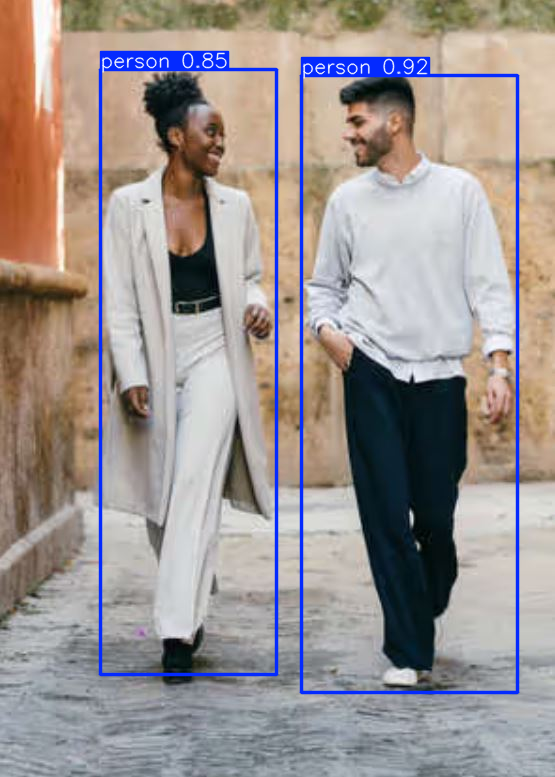

Procesando: ldogcap.JPG

image 1/1 /content/imagenes/ldogcap.JPG: 640x480 2 persons, 1 dog, 1 couch, 206.5ms
Speed: 3.8ms preprocess, 206.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)


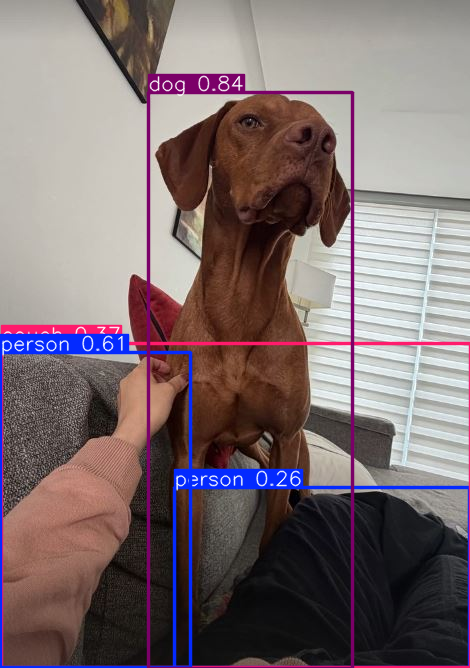

Procesando: pt.JPG

image 1/1 /content/imagenes/pt.JPG: 640x640 3 couchs, 270.2ms
Speed: 6.6ms preprocess, 270.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


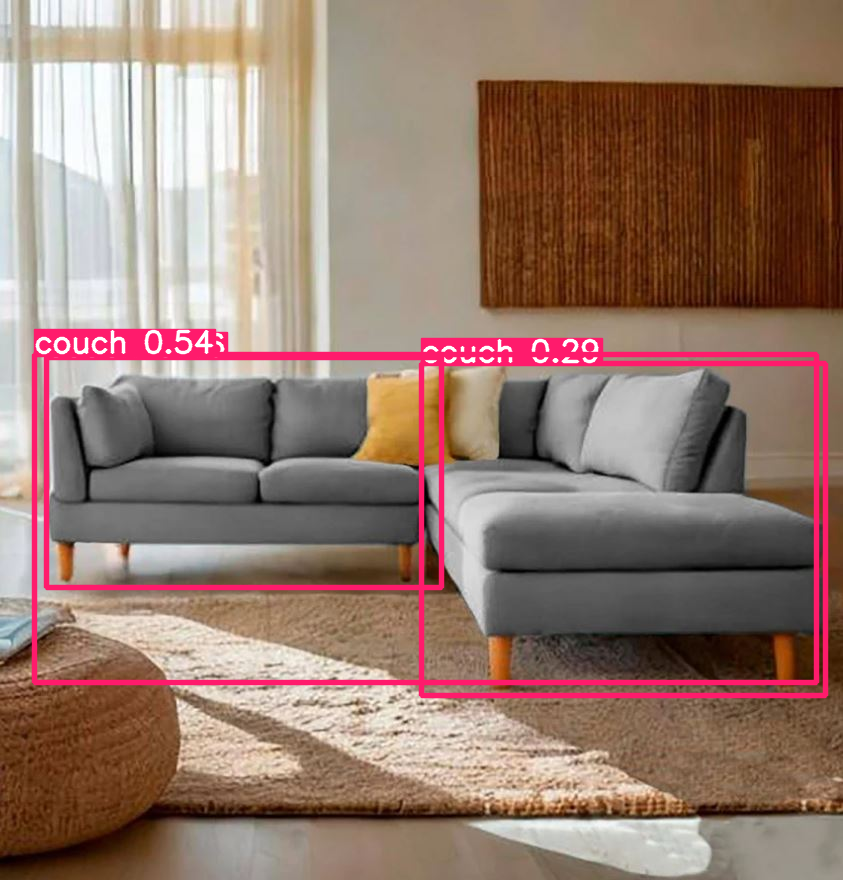

PROCESO FINALIZADO
Archivo generado: resultados_detallados.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================
# DETECCIÓN DE OBJETOS EN MÚLTIPLES IMÁGENES
# ============================================

# --------------------------------------------
# 1. INSTALACIÓN DE DEPENDENCIAS
# --------------------------------------------
import sys

try:
    from ultralytics import YOLO
    import cv2
except:
    print("Instalando dependencias...")
    !pip install -q ultralytics opencv-python
    from ultralytics import YOLO
    import cv2

import os
import csv
from datetime import datetime

# Detectar si estamos en Colab
EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    from google.colab import files
    from google.colab.patches import cv2_imshow

# --------------------------------------------
# 2. SUBIR IMÁGENES (solo en Colab)
# --------------------------------------------
if EN_COLAB:
    print("Sube tus imágenes (pueden ser varias)...")
    uploaded = files.upload()

    # Crear carpeta
    os.makedirs("imagenes", exist_ok=True)

    # Guardar archivos en carpeta
    for nombre in uploaded.keys():
        with open(os.path.join("imagenes", nombre), "wb") as f:
            f.write(uploaded[nombre])

# --------------------------------------------
# 3. CONFIGURACIÓN
# --------------------------------------------
CARPETA_IMAGENES = "imagenes"
ARCHIVO_SALIDA = "resultados_detallados.csv" # Cambiamos el nombre para reflejar el nuevo contenido

# --------------------------------------------
# 4. VALIDAR CARPETA
# --------------------------------------------
if not os.path.exists(CARPETA_IMAGENES):
    raise Exception(f"No existe la carpeta: {CARPETA_IMAGENES}")

# --------------------------------------------
# 5. CARGAR MODELO
# --------------------------------------------
print("Cargando modelo YOLO...")
model = YOLO("yolov8n.pt")
print("Modelo listo")

# --------------------------------------------
# 6. PROCESAMIENTO DE IMÁGENES
# --------------------------------------------
# Ahora esta lista guardará una fila por CADA objeto detectado
resultados = []

for archivo in os.listdir(CARPETA_IMAGENES):
    ruta = os.path.join(CARPETA_IMAGENES, archivo)

    # Filtrar solo imágenes
    if not archivo.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    print(f"Procesando: {archivo}")

    results = model(ruta)

    for r in results:
        if r.boxes is None:
            continue

        for box in r.boxes:
            # 1. Obtener el ID de la clase y su nombre en texto
            cls_id = int(box.cls[0].item())
            nombre_clase = model.names[cls_id]

            # 2. Obtener el nivel de confianza
            conf = float(box.conf[0].item())

            # 3. Obtener coordenadas del recuadro (x1, y1, x2, y2)
            # x1, y1 (esquina superior izquierda) y x2, y2 (esquina inferior derecha)
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            # Filtramos por confianza (puedes ajustar el 0.4 si quieres más o menos objetos)
            if conf > 0.4:
                # Guardamos todos los datos relevantes del objeto actual
                resultados.append([
                    archivo,
                    nombre_clase,                  # Ej: 'person', 'car', 'dog'
                    round(conf, 4),                # Confianza redondeada a 4 decimales
                    round(x1, 2),                  # Coordenada X1
                    round(y1, 2),                  # Coordenada Y1
                    round(x2, 2),                  # Coordenada X2
                    round(y2, 2),                  # Coordenada Y2
                    datetime.now().strftime("%Y-%m-%d %H:%M:%S") # Fecha y hora limpia
                ])

    # ----------------------------------------
    # VISUALIZAR RESULTADO (opcional)
    # ----------------------------------------
    for r in results:
        img_resultado = r.plot()

        if EN_COLAB:
            cv2_imshow(img_resultado)
        else:
            cv2.imshow("Resultado", img_resultado)
            cv2.waitKey(500)

# --------------------------------------------
# 7. GUARDAR CSV
# --------------------------------------------
with open(ARCHIVO_SALIDA, mode='w', newline='') as f:
    writer = csv.writer(f)
    # Actualizamos los encabezados del CSV para reflejar la nueva información
    writer.writerow([
        "Imagen",
        "Objeto_Detectado",
        "Nivel_Confianza",
        "Coord_X1",
        "Coord_Y1",
        "Coord_X2",
        "Coord_Y2",
        "Fecha_Procesamiento"
    ])
    writer.writerows(resultados)

print("====================================")
print("PROCESO FINALIZADO")
print("Archivo generado:", ARCHIVO_SALIDA)

# --------------------------------------------
# 8. DESCARGAR RESULTADOS (Colab)
# --------------------------------------------
if EN_COLAB:
    files.download(ARCHIVO_SALIDA)

# --------------------------------------------
# 9. LIMPIAR VENTANAS (solo local)
# --------------------------------------------
if not EN_COLAB:
    cv2.destroyAllWindows()